# Geospatial Data Analysis Lab: Steel Plants Dataset


**Learning Objectives:**
- Perform exploratory data analysis (EDA) on geospatial datasets
- Visualize geospatial data using interactive maps with Plotly
- Merge granular exposure / population data (LitPop) with asset locations
- Aggregate data at the company level
- Integrate geospatial visualizations into a Streamlit dashboard

**Dataset:** Download the Global Energy Monitor [Global Iron and Steel Tracker](https://globalenergymonitor.org/projects/global-iron-steel-tracker) (formerly Global Steel Plant Tracker). Use the plant-level download from that page and place the file in the same folder as this notebook (or update the load path accordingly).

---


## Submission info

Work in **groups of up to 4**. Fill in every member before submitting.

| # | Full name | Student ID |
|---|-----------|------------|
| 1 |  |  |
| 2 |  |  |
| 3 |  |  |
| 4 |  |  |

**Group / repo name:** `aidams-lab1-<surname1>-<surname2>-...`  
**Submitter (one person):**  
**Repo URL:**  
**Streamlit Cloud URL (bonus):**  

### What to submit
- This notebook (`lab_1.ipynb`) with all parts completed and cells run
- `app.py` (Part 6)
- Processed data exports used by the dashboard (e.g. CSV/Parquet), if applicable
- (Bonus) Deployed Streamlit Cloud app link, if completed

<span style="color: #FFD700; font-weight: bold">Send submission info to my email (1 email per group)</span> — include the GitHub repo URL and, if you did the bonus, the Streamlit Cloud link.


## Upload to GitHub

Follow this checklist (one repo per group):

1. Create a **private** repository (or use the course organization if provided).
2. Name it using the pattern above, e.g. `aidams-lab1-ali-ben-chen-diaz`.
3. Add your files (`lab_1.ipynb`, `app.py`, exports, and a short `README.md` with how to run the dashboard).
5. Commit and push:
   ```bash
   git init
   git add lab_1.ipynb app.py .gitignore README.md
   git commit -m "Complete AIDAMS Lab 1"
   git branch -M main
   git remote add origin <YOUR_REPO_URL>
   git push -u origin main
   ```
6. Invite the instructor (or open the assignment link) and paste the **repo URL** in the Submission info table above.

**Done when:** all 4 names are filled in, the notebook contains all outputs (no need for the instructor to re-run it), maps are visible, and `streamlit run app.py` works from the repo.

**Bonus (optional):** deploy `app.py` to Streamlit Cloud and paste the public app URL above / in your submission email.


## Part 1: Setup and Data Loading

Import the necessary libraries and load the steel plants dataset.

**Tip:** After loading, run `df.columns` and `df.head()`. Column names in the file may differ slightly by release — inspect them and adapt your code accordingly.


In [35]:
# Import required libraries
# - pandas for data manipulation
# - numpy for numerical operations
# - plotly.express and plotly.graph_objects for interactive visualizations
# - Any other libraries you need

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import tables as pt
import geopandas

In [2]:
# Load the steel plants dataset
# Tip: start with df.columns / df.head() and adapt names if your file differs slightly
#
# Common columns in this steel plant dataset:
# - Plant name (English)
# - Owner
# - Country/Area, Region
# - Coordinates  (often a single "lat, lon" string — not separate latitude/longitude columns)
# - Plant age (years)
# - Capacity field: usually "Nominal crude steel capacity (ttpa)" (check your df.columns to confirm the exact name)
#   (Older datasets may also include additional fields like ferronickel/sinter/coking/pelletizing capacities, 
#    but most analyses focus on nominal crude steel capacity as the main output.)

df = pd.read_excel("gem-download/Plant-level_data_Global_Iron_and_Steel_Tracker_June_2026_V1.xlsx", sheet_name="Plant data")

df.head()



,GEM plant ID,Plant name (English),Plant name (other language),Other plant names (English),Other plant names (other language),Owner,Owner (other language),Owner GEM entity ID,Owner PermID,SOE status,...,Steel products,Steel sector end users,Workforce size,ISO 14001,ISO 50001,ResponsibleSteel certification,Main production equipment,Power source,Iron ore source,Met coal source
0,P100000120882,Aba Iron and Steel Payas plant,ABA DEMİR ÇELİK,"EEY Iron and Steel, Nursan Steel Payas Plant (...",NaN,ABA Çelik Demir LŞ,ABA Demir ve Çelik İthalat İhracat Ticaret,E100000131190,unknown,NaN,...,"billet, wire rod, angle, flat, bar, square bar...",unknown,900,unknown,unknown,no,EAF,unknown,unknown,NaN
1,P100000120753,Abba Steel Ohangwena steel plant,NaN,Groot Suisse Oshana plant,NaN,Abba Steel Ltd,NaN,E100001012072,unknown,NaN,...,"billet, wire rod, rebar",building and infrastructure,5500,unknown,unknown,no,EAF,unknown,unknown,NaN
2,P100000120802,Abinsk Electric Steel Works,АЭМЗ,"AESW, ASW, AEMZ, AEMK",Абинский ЭлектроМеталлургический завод,Abinski Elektrometallurgicheski Zavod LLC,"ООО ""АБИНСКИЙ ЭЛЕКТРОМЕТАЛЛУРГИЧЕСКИЙ ЗАВОД""",E100000130999,5039667129,NaN,...,"wire rod, rebar, bar, billet, round bar, wire",unknown,4500,2025-10-06 00:00:00,unknown,no,EAF,unknown,NaN,unknown
3,P100000120020,Abul Khair Steel Sitakunda plant,আবুল খায়ের স্টিল মেল্টিং লিমিটেড,"AKS Long Steel, AKS Sitakund, AKS Melting, Abu...",NaN,Abul Khair Steel Ltd,NaN,E100000131068,5074007077,NaN,...,"billet, rebar","building and infrastructure, energy",unknown,unknown,unknown,no,EAF,"100MW Power Plant, in progress 50MW solar plant",unknown,unknown
4,P100000120620,Acciaierie d'Italia Taranto steel plant,NaN,"ILVA Taranto steel plant (predecessor), ILVA S...",NaN,Acciaierie d'italia SpA,NaN,E100001010116,5067495106,Full,...,"pipe, tube, flat","automotive, building and infrastructure, energ...",11000,2025-04-30 00:00:00,2025-12-04 00:00:00,no,DRI; EAF; BF; BOF,unknown,unknown,unknown


---
## Part 2: Exploratory Data Analysis

Answer the following questions through your analysis:


### Question 1: Data Overview
**Task:** Display basic information about the dataset.
- How many steel plants are in the dataset?
- What are the column names and data types? (use `df.columns` / `df.dtypes` or `df.info()`, then adapt later code to the names you see)
- Are there any missing values?


In [3]:
# Display dataset shape

df.shape

(1293, 44)

In [4]:
# Display column information and data types
# Start here: print(df.columns) and adapt column names in later cells if needed

df.columns

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1293 entries, 0 to 1292
Data columns (total 44 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   GEM plant ID                        1293 non-null   str   
 1   Plant name (English)                1293 non-null   str   
 2   Plant name (other language)         791 non-null    str   
 3   Other plant names (English)         742 non-null    str   
 4   Other plant names (other language)  335 non-null    str   
 5   Owner                               1293 non-null   str   
 6   Owner (other language)              578 non-null    str   
 7   Owner GEM entity ID                 1293 non-null   str   
 8   Owner PermID                        1293 non-null   object
 9   SOE status                          212 non-null    str   
 10  Parent (English)                    1293 non-null   str   
 11  Parent GEM entity ID                1293 non-null   str   
 12  Par

In [5]:
# Check for missing values
df.isna()   # Array with True if values are missing and False if not

df.isna().sum() 

# There are missing values, especially in the columns :
# Plant name (other language), Other plant names (English), Other plant names (other language), Owner(other language), SOE status and Location Adress (other language)
# We can see that most missing values are linked to the other language, which does make sense as English is prioritized for worldwide use of the dataset.

GEM plant ID                             0
Plant name (English)                     0
Plant name (other language)            502
Other plant names (English)            551
Other plant names (other language)     958
Owner                                    0
Owner (other language)                 715
Owner GEM entity ID                      0
Owner PermID                             0
SOE status                            1081
Parent (English)                         0
Parent GEM entity ID                     0
Parent PermID                            0
Location address                         0
Location address (other language)      794
Municipality                             0
Subnational unit                         0
Country/area                             0
Region                                   0
Coordinates                              0
Coordinate accuracy                      0
GEM wiki page                            0
Plant age                               61
Announced d

### Question 2: Statistical Summary
**Task:** Generate descriptive statistics for numerical columns.
- What is the average plant capacity? (sum relevant capacity columns in ttpa if needed, e.g. sinter / coking / pelletizing / ferronickel)
- What is the range of latitudes and longitudes? (you will likely need to parse `Coordinates` first — see Part 3 hint)
- What is the distribution of `Plant age (years)`?


In [6]:
capacity_cols = [
    'Ferronickel capacity (ttpa)', 
    'Sinter plant capacity (ttpa)', 
    'Coking plant capacity (ttpa)', 
    'Pelletizing plant capacity (ttpa)'
]

for col in capacity_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

total_capacity = df[capacity_cols].sum(axis=1)
average_capacity = total_capacity.mean()

print(f"Average plant capacity: {average_capacity:.2f} ttpa")

Average plant capacity: 1183.42 ttpa


In [7]:
coords = df['Coordinates'].astype(str).str.split(',', expand=True)

df['latitude'] = pd.to_numeric(coords[0], errors='coerce')
df['longitude'] = pd.to_numeric(coords[1], errors='coerce')

print(f"Latitude range:  {df['latitude'].min()} to {df['latitude'].max()}")
print(f"Longitude range: {df['longitude'].min()} to {df['longitude'].max()}")

Latitude range:  -37.831379 to 67.189096
Longitude range: -123.163599 to 174.728098


count    1125.00000
mean       38.78200
std        36.42716
min         0.00000
25%        16.00000
50%        25.00000
75%        55.00000
max       287.00000
Name: Plant age (years), dtype: float64


<Axes: title={'center': "Distribution de l'âge des usines"}, ylabel='Frequency'>

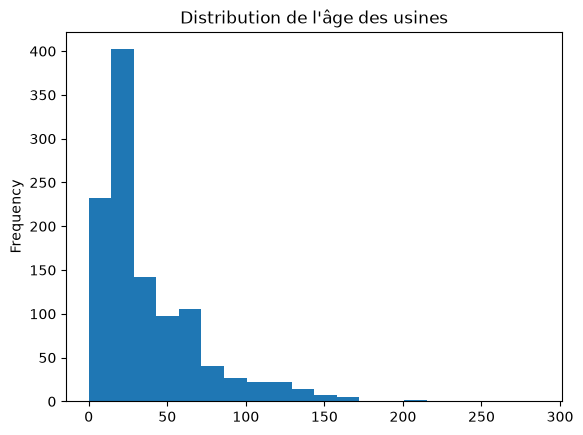

In [11]:
df['Plant age (years)'] = pd.to_numeric(df['Plant age'], errors='coerce')
print(df['Plant age (years)'].describe())

# Plotting the distribution
df['Plant age (years)'].plot(kind='hist', bins=20, title='Distribution de l\'âge des usines')

### Question 3: Geographic Distribution
**Task:** Analyze the geographic distribution of steel plants.
- Which `Country/Area` or `Region` values have the most steel plants?
- What is the distribution of plants by `Owner` (company)?


Plant counts by country/area:


,Country/Area,Plant count
0,China,458
1,India,113
2,United States,90
3,Iran,56
4,Japan,42
...,...,...
86,Bulgaria,1
87,Bahrain,1
88,Singapore,1
89,Mozambique,1


Plant counts by region:


,Region,Plant count
0,Asia Pacific,765
1,Europe,184
2,North America,113
3,Middle East,90
4,Africa,51
5,Eurasia,47
6,Central & South America,43


<Axes: title={'center': 'Top 15 Countries/Areas by Number of Steel Plants'}, xlabel='Number of plants', ylabel='Country/area'>

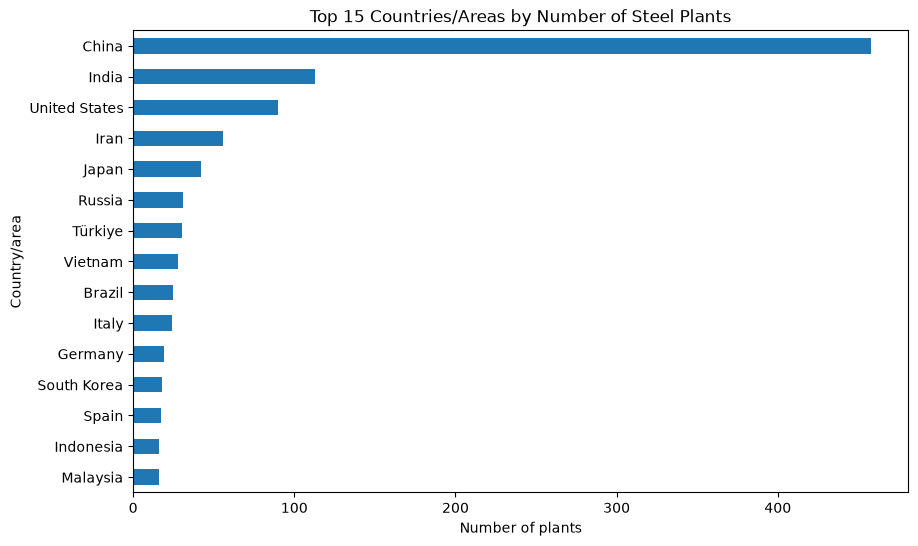

In [12]:
# Count plants by country/region

country_counts = (
    df['Country/area']
    .value_counts()
    .rename_axis('Country/Area')
    .reset_index(name='Plant count')
)

region_counts = (
    df['Region']
    .value_counts()
    .rename_axis('Region')
    .reset_index(name='Plant count')
)

print('Plant counts by country/area:')
display(country_counts)

print('Plant counts by region:')
display(region_counts)

country_counts.head(15).set_index('Country/Area')['Plant count'].sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Top 15 Countries/Areas by Number of Steel Plants',
    xlabel='Number of plants',
    ylabel='Country/area'
)


Top 20 owners by number of steel plants:


,Owner,Plant count
0,Nucor Corp,13
1,Cleveland-Cliffs Inc,12
2,Nippon Steel Corp,10
3,Commercial Metals Co,8
4,Gerdau Ameristeel Corp,8
5,Steel Authority of India Ltd,8
6,SteelAsia Manufacturing Corp,7
7,ArcelorMittal Brasil SA,6
8,ArcelorMittal SA,6
9,Liberty Steel Group,6


<Axes: title={'center': 'Top 20 Owners by Number of Steel Plants'}, xlabel='Number of plants', ylabel='Owner'>

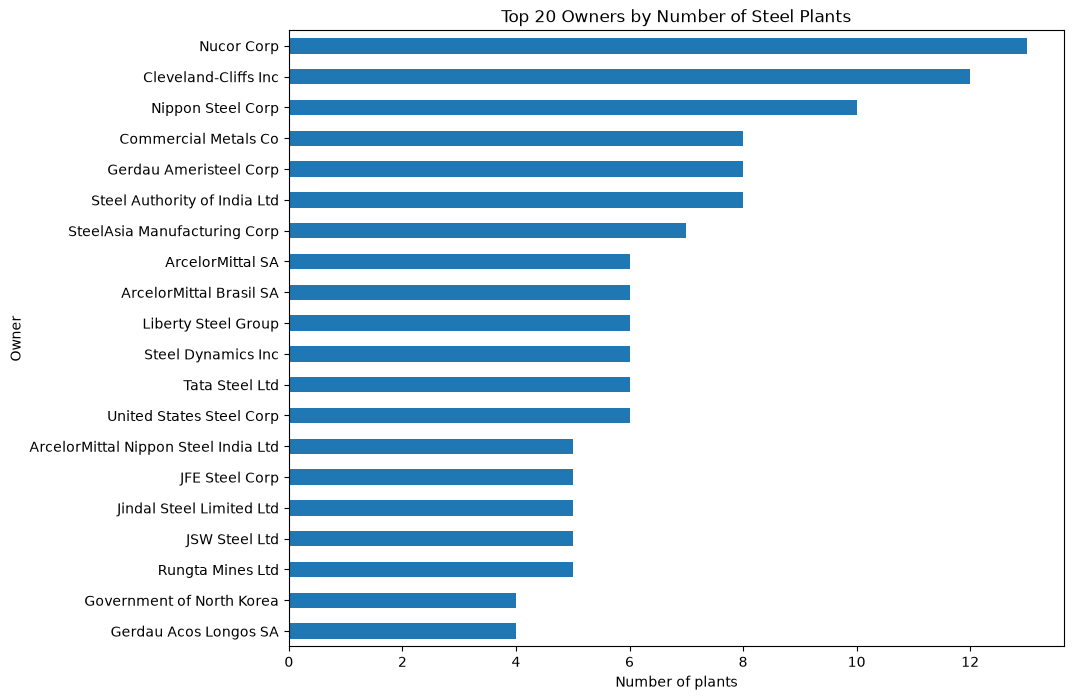

In [13]:
# Count plants by Owner (company)
owner_counts = (
    df['Owner']
    .value_counts()
    .rename_axis('Owner')
    .reset_index(name='Plant count')
)

print('Top 20 owners by number of steel plants:')
display(owner_counts.head(20))

owner_counts.head(20).set_index('Owner')['Plant count'].sort_values().plot(
    kind='barh',
    figsize=(10, 8),
    title='Top 20 Owners by Number of Steel Plants',
    xlabel='Number of plants',
    ylabel='Owner'
)


### Question 4: Capacity Analysis
**Task:** Analyze the capacity distribution.
- What is the total global steel production capacity? (sum the capacity columns you are using)
- Which `Owner` values have the highest total capacity?
- How does capacity vary by `Region` or `Country/Area`?


In [14]:
# Calculate total capacity

capacity_cols = [col for col in df.columns if '(ttpa)' in col]
for col in capacity_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['total_capacity'] = df[capacity_cols].sum(axis=1)
global_capacity = df['total_capacity'].sum()

print(f"Total global steel production capacity: {global_capacity:,.2f} ttpa")


Total global steel production capacity: 1,530,167.00 ttpa


In [15]:
# Group by Owner and sum capacity

owner_capacity = df.groupby('Owner')['total_capacity'].sum().sort_values(ascending=False).reset_index()

print("Top 10 Owners by capacity:")
owner_capacity.head(10)

Top 10 Owners by capacity:


,Owner,total_capacity
0,JSW Steel Ltd,50935.0
1,Steel Authority of India Ltd,43591.0
2,Jindal Steel Odisha Ltd,42670.0
3,Jindal Steel Limited Ltd,39710.0
4,Rungta Mines Ltd,34955.0
5,Tata Steel Ltd,33787.0
6,Lebedinskiy GOK JSC,31031.0
7,Progressive Green Solutions JV,30000.0
8,JSW Jharkhand Steel Ltd,29600.0
9,Maanshan Iron & Steel Co Ltd,25540.0


In [16]:
# Capacity by Country/area and Region

country_capacity = df.groupby('Country/area')['total_capacity'].sum().sort_values(ascending=False).reset_index()
region_capacity = df.groupby('Region')['total_capacity'].sum().sort_values(ascending=False).reset_index()

print("Top 10 Countries/Areas by capacity:")
display(country_capacity.head(10))

print("Capacity by Region:")
region_capacity

Top 10 Countries/Areas by capacity:


,Country/area,total_capacity
0,India,469533.0
1,China,445121.0
2,Russia,133948.0
3,Iran,82785.0
4,Brazil,53170.0
5,Japan,37445.0
6,Ukraine,37044.0
7,Australia,30700.0
8,Germany,28580.0
9,France,24530.0


Capacity by Region:


,Region,total_capacity
0,Asia Pacific,1033993.0
1,Eurasia,147694.0
2,Europe,121884.0
3,Middle East,97585.0
4,Central & South America,58415.0
5,Africa,42985.0
6,North America,27611.0


---
## Part 3: Geospatial Visualization with Plotly

Create interactive maps to visualize the steel plants' locations and characteristics.


### Exercise 1: Basic Scatter Map
**Task:** Create a scatter map showing all steel plant locations.
- Parse `Coordinates` into numeric `Latitude` and `Longitude` (see hint in the code cell)
- Color points by `Country/Area` or `Region`
- Add hover information showing `Plant name (English)`, `Owner`, and capacity


In [46]:
#Based on the further analysis, we saw some plants with NA or unknown capacity. So we filter them out to not bias our maps and legends
df = df[df['total_capacity'] != 0].copy()

In [47]:
# Create a scatter_geo or scatter_mapbox plot
# Hint: Use plotly.express.scatter_geo() or scatter_mapbox()
#
# Coordinates hint:
#   The dataset usually stores location in a single Coordinates column like "lat, lon".
#   Split it before plotting
def split(x, pos):
    return x.split(', ')[pos]
df['Lat'] = df['Coordinates'].apply(lambda x: split(x, 0))
df['Lon'] = df['Coordinates'].apply(lambda x: split(x, 1))
px.scatter_geo(data_frame=df, lat='Lat', lon='Lon', hover_name="Plant name (English)")

### Exercise 2: Sized Markers by Capacity
**Task:** Create a map where marker size represents plant capacity.
- Larger markers for higher capacity plants
- Color by `Owner`
- Include interactive hover details (`Plant name (English)`, `Country/Area`, capacity, etc.)


In [48]:
# Create scatter map with size parameter based on capacity
px.scatter_geo(data_frame=df, lat='Lat', lon='Lon', hover_name="Plant name (English)", hover_data=('Country/area'), color="Owner", size='total_capacity')

### Exercise 3: Density Heatmap
**Task:** Create a density map showing concentration of steel plants.
- Use Plotly's density_mapbox to show clustering
- Identify regions with high plant density


In [49]:
# Create density heatmap
# Hint: Use plotly.express.density_mapbox()

px.density_map(data_frame=df, lat='Lat', lon='Lon', )

---
## Part 4: Merging Exposure / Population Data with Assets

Steel plants sit in real places -- next to people, housing, and economic activity. In this part you will attach **granular socio-economic exposure data** to each plant so you can ask: *who and what is near this industrial asset?*

We use **LitPop** (ETH Zurich): a global dataset that combines **population** and **produced capital / asset value** on a fine geographic grid. It is widely used in disaster- and climate-risk analysis as a measure of **exposure**. It is **not** classical environmental monitoring (not air quality, emissions, or weather).

**Goal:** spatially link LitPop grid cells (or sample points) to steel plant locations (nearest neighbor or spatial join), then use the merged fields in maps and later company-level summaries.


### Exercise 1: Load LitPop (Exposure) Data
**Task:** Load the LitPop sample and inspect it.

- **Samples for this lab (recommended):** LitPop sample files are available on Moodle (litpop data). Use these for the merge exercises below.
- **Full LitPop dataset (optional):** [ETH Research Collection – LitPop](https://www.research-collection.ethz.ch/entities/researchdata/12dcfc4f-9d03-463a-8d6b-76c0dc73cdc8)

- Expected columns (may vary by extract): location identifiers, latitude, longitude, population and/or asset-value / exposure fields, etc.

Briefly note what each column represents and the spatial resolution of the sample.


In [50]:
# Load LitPop sample (exposure / population–asset data)
df_litpop_ch = pd.read_hdf('litpop/LitPop_pc_300_arcsec_CHN_v1.hdf5')
df_litpop_in = pd.read_hdf('litpop/LitPop_pc_300_arcsec_IND_v1.hdf5')
df_litpop_jp = pd.read_hdf('litpop/LitPop_pc_300_arcsec_JPN_v1.hdf5')

In [51]:
# Inspect LitPop data (columns, dtypes, missing values, value ranges)
df_litpop_ch.head(10)

,value,latitude,longitude,geometry,region_id,impf_
0,5.280440e+09,20.041667,110.208333,POINT (110.20833333 20.04166667),156,1
1,4.040559e+07,20.041667,110.625000,POINT (110.625 20.04166667),156,1
2,4.190224e+07,20.041667,110.708333,POINT (110.70833333 20.04166667),156,1
3,8.813872e+07,19.958333,109.541667,POINT (109.54166667 19.95833333),156,1
4,1.879947e+08,19.958333,109.625000,POINT (109.625 19.95833333),156,1
5,6.058794e+08,19.958333,109.708333,POINT (109.70833333 19.95833333),156,1
6,7.865646e+07,19.958333,109.791667,POINT (109.79166667 19.95833333),156,1
7,2.466372e+07,19.958333,109.875000,POINT (109.875 19.95833333),156,1
8,5.126086e+07,19.958333,109.958333,POINT (109.95833333 19.95833333),156,1
9,5.147673e+08,19.958333,110.041667,POINT (110.04166667 19.95833333),156,1


In [52]:
for i in [df_litpop_ch, df_litpop_in, df_litpop_jp]:
    display(i.info())
    display(i.describe())

<class 'pandas.DataFrame'>
Index: 136991 entries, 0 to 136990
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   value      136991 non-null  float64
 1   latitude   136991 non-null  float64
 2   longitude  136991 non-null  float64
 3   geometry   136991 non-null  object 
 4   region_id  136991 non-null  int64  
 5   impf_      136991 non-null  int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 7.3+ MB


None

,value,latitude,longitude,region_id,impf_
count,1.369910e+05,136991.000000,136991.000000,136991.0,136991.0
mean,2.870462e+08,36.557225,103.832300,156.0,1.0
std,3.697379e+09,7.145996,14.370976,0.0,0.0
min,0.000000e+00,18.208333,73.625000,156.0,1.0
25%,2.016376e+04,31.125000,91.208333,156.0,1.0
50%,3.790894e+05,36.708333,104.708333,156.0,1.0
75%,4.678025e+06,41.875000,115.708333,156.0,1.0
max,2.873477e+11,53.541667,134.708333,156.0,1.0


<class 'pandas.DataFrame'>
Index: 40101 entries, 0 to 40100
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   value      40101 non-null  float64
 1   latitude   40101 non-null  float64
 2   longitude  40101 non-null  float64
 3   geometry   40101 non-null  object 
 4   region_id  40101 non-null  int64  
 5   impf_      40101 non-null  int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 2.1+ MB


None

,value,latitude,longitude,region_id,impf_
count,4.010100e+04,40101.000000,40101.000000,40101.0,40101.0
mean,1.705707e+08,22.889661,79.608136,356.0,1.0
std,1.088456e+09,5.539521,5.888910,0.0,0.0
min,1.274298e+03,6.875000,68.208333,356.0,1.0
25%,1.956703e+06,19.375000,75.625000,356.0,1.0
50%,1.445965e+07,23.458333,78.291667,356.0,1.0
75%,7.542776e+07,26.625000,82.458333,356.0,1.0
max,5.192679e+10,35.458333,97.291667,356.0,1.0


<class 'pandas.DataFrame'>
Index: 5499 entries, 0 to 5498
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   value      5499 non-null   float64
 1   latitude   5499 non-null   float64
 2   longitude  5499 non-null   float64
 3   geometry   5499 non-null   object 
 4   region_id  5499 non-null   int64  
 5   impf_      5499 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 300.7+ KB


None

,value,latitude,longitude,region_id,impf_
count,5.499000e+03,5499.000000,5499.000000,5499.0,5499.0
mean,4.282200e+09,37.559564,137.985141,392.0,1.0
std,2.651444e+10,3.862920,4.127625,0.0,0.0
min,1.039569e+05,24.291667,122.958333,392.0,1.0
25%,5.521340e+06,34.791667,134.791667,392.0,1.0
50%,2.460568e+07,36.458333,139.041667,392.0,1.0
75%,3.162187e+08,40.541667,141.041667,392.0,1.0
max,5.044057e+11,45.458333,145.791667,392.0,1.0


### Exercise 2: Spatial Join or Nearest Neighbor Matching
**Task:** Attach LitPop exposure attributes to each steel plant based on geographic proximity.
- Match each plant to the **nearest LitPop grid cell / sample point** (or use a spatial join if you work with polygons)
- Consider `geopandas`, a ball-tree / KD-tree nearest-neighbor search, or haversine distances
- Keep plant identifiers and the LitPop fields you will use later (e.g. population, asset value / exposure)

You should end up with one row per plant (or a clear many-to-one rule if you aggregate nearby cells).


In [53]:
# Calculate distances or perform spatial join
# Hint: You might calculate haversine distance or use a spatial library

df_combined_litpop = pd.concat([df_litpop_ch, df_litpop_in, df_litpop_jp])
geo_lit = geopandas.GeoDataFrame(df_combined_litpop, geometry=geopandas.points_from_xy(df_combined_litpop.longitude, df_combined_litpop.latitude), crs="EPSG:4326")
geo_plants = geopandas.GeoDataFrame(df, geometry=geopandas.points_from_xy(df.longitude, df.latitude), crs='EPSG:4326')

In [54]:
nearest_df = geopandas.sjoin_nearest(
    geo_plants, 
    geo_lit, 
    how="left", 
    distance_col="distance_to_nearest"
)

/Users/iamgeorgerieh/Documents/aidams-lab1-riekhakainen-montluc-destal-vlandas/.venv/lib/python3.13/site-packages/geopandas/array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [55]:
nearest_df.head()

,GEM plant ID,Plant name (English),Plant name (other language),Other plant names (English),Other plant names (other language),Owner,Owner (other language),Owner GEM entity ID,Owner PermID,SOE status,...,Lat,Lon,geometry,index_right,value,latitude_right,longitude_right,region_id,impf_,distance_to_nearest
14,P100000120757,African Natural Resources and Mines Kaduna ste...,NaN,"African Industries Group, ANRML Kaduna Steel P...",NaN,African Natural Resources & Mines Ltd,NaN,E100000131098,unknown,NaN,...,9.4627150,7.3680000,POINT (7.368 9.46272),19501,64633.832129,23.625000,68.208333,356,1,62.466923
22,P100000120756,Ajaokuta Steel plant,NaN,NaN,NaN,Ajaokuta Steel Co Ltd,NaN,E100000002408,5040059767,Full,...,7.5113360,6.6893640,POINT (6.68936 7.51134),19501,64633.832129,23.625000,68.208333,356,1,63.594290
23,P100000121166,Aktobe Generatsiya steel plant,Cталеплавильный завод ТОО «Актобе Генерация»,Aktobe Generatsia steel plant,NaN,Aktobe Generatsiya LLC,"""АКТОБЕ ГЕНЕРАЦИЯ"" ЖШС",E100001012067,unknown,NaN,...,50.3551170,57.1451190,POINT (57.14512 50.35512),47524,69838.970005,39.958333,73.958333,156,1,19.768088
25,P100000120835,Al Ittefaq Arab Steel Dammam plant,حديد الإتفاق,"ISPC, Arab Steel, ASCO",الشركة العريبة للحديد,Arab Steel Co,NaN,E100000131037,5050911102,NaN,...,26.2779170,49.9491770,POINT (49.94918 26.27792),18692,54845.716740,23.875000,68.208333,356,1,18.416590
29,P100000120905,Alchevsk Metallurgical Plant,Алчевский металлургический комбинат,"AMK, Alchevsk Iron & Steel plant","Алчевський металургійний комбінат, Алчевський ...",Alchevsk Metallurgical Plant PJSC,"ПАТ ""АЛЧЕВСЬКИЙ МЕТАЛУРГІЙНИЙ КОМБІНАТ""",E100001012119,5000049750,NaN,...,48.4781110,38.7707870,POINT (38.77079 48.47811),52059,293.883167,39.291667,73.625000,156,1,36.044513


### Exercise 3: Visualize Plants with Exposure Context
**Task:** Create a map of steel plants enriched with LitPop fields.
- Color plants by a LitPop metric (e.g. local population or asset exposure)
- Size markers by plant capacity
- Add hover details with both plant attributes (`Plant name (English)`, `Owner`, capacity) and the matched LitPop values

Interpret briefly: where do large plants sit relative to high population / high asset-value areas?


In [56]:
# Create visualization of plants colored by LitPop exposure metrics
px.scatter_geo(nearest_df, lat="Lat", lon='Lon', color='value', size='total_capacity', hover_name='Plant name (English)')

---
## Part 5: Company-Level Aggregation

Aggregate data at the company level to analyze corporate footprints — including capacity and the LitPop exposure context you attached in Part 4.


### Exercise 1: Aggregate Metrics by Company
**Task:** Group plants by company (`Owner`) and calculate aggregate metrics.
- Total capacity per company
- Number of plants per company
- Average LitPop exposure metrics per company (from Part 4)
- Geographic spread (e.g. number of `Country/Area` or `Region` values)


In [57]:
# Group by company and aggregate



### Exercise 2: Company Headquarters or Centroid
**Task:** Calculate a representative location for each company.
- Option 1: Use the centroid of all plant locations
- Option 2: Use the location of the largest plant
- Option 3: Assign actual headquarters coordinates


In [58]:
# Calculate company representative locations



### Exercise 3: Visualize Company-Level Data
**Task:** Create a map showing companies with aggregated metrics.
- Show one marker per company at the representative location
- Size by total capacity
- Color by average LitPop exposure (or another Part 4 metric)
- Hover information with company summary statistics


In [59]:
# Create company-level visualization



---
## Part 6: Streamlit Dashboard Integration

Prepare your visualizations for deployment in a Streamlit dashboard.


### Exercise 1: Create Dashboard Script Structure
**Task:** Create a Streamlit app file (`app.py`) with the following structure:

```python
# Import streamlit and other necessary libraries

# Set page configuration

# Title and description

# Sidebar for filters
# - Company selector
# - Region/country filter
# - Capacity range slider

# Main content area
# - KPI metrics (total plants, total capacity, etc.)
# - Interactive map
# - Data table

# Footer with data sources and notes
```


### Exercise 1: Prepare Data for Dashboard
**Task:** Save your processed data to files that the dashboard will load.
- Export cleaned plant data
- Export merged plant + LitPop exposure data
- Export company-level aggregations
- Save as CSV or Parquet for efficient loading


In [60]:
# Save processed datasets



### Exercise 2: Display relevant information from your exploratory analysis into the dashboard

In [61]:
# This cell is for notes/observations about your dashboard
# What works well?
# What could be improved?
# Any performance issues with large datasets?



---
## Bonus (optional): Deploy to Streamlit Cloud

Deploy your dashboard so it runs in the browser without local setup.

**Task:**
1. Make sure `app.py` and any required data files are in your GitHub repo
2. Go to [https://share.streamlit.io](https://share.streamlit.io) (Streamlit Community Cloud)
3. Sign in with GitHub, select your repo, and deploy `app.py`
4. Copy the public app URL

**Submit:** paste the Streamlit Cloud link in the **Submission info** section at the top **and** include it in your group's submission email (with the GitHub repo URL).


---
## Lab Summary and Key Takeaways

**What you learned:**
- How to perform EDA on geospatial datasets
- Creating interactive maps with Plotly for geospatial data
- Merging LitPop exposure / population data with assets based on geographic proximity
- Aggregating geospatial data at different levels (asset vs. company)
- Building interactive dashboards with Streamlit

**Next Steps:**
- Explore other geospatial libraries (GeoPandas, Folium, Kepler.gl)
- Learn about coordinate reference systems (CRS) and projections
- Practice with other datasets (buildings, utilities, transportation)
- (Bonus) Deploy your dashboard to Streamlit Cloud and share the link in your submission email
